In [2]:
# Step 0: imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Optional nicer display in notebooks
pd.set_option('display.max_columns', 100)
pd.set_option('display.precision', 3)

# Load dataset
df = pd.read_csv('StudentsPerformance.csv')  # change filename/path if needed

# Quick peek
print("Rows,Cols:", df.shape)
display(df.head())

Rows,Cols: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# Step 1: Size + missing values
num_rows, num_cols = df.shape
missing = df.isna().sum()
print("\n--- Size & Missing ---")
print(f"Observations (rows): {num_rows}")
print(f"Variables (cols): {num_cols}")
print("Missing per column:")
print(missing)

# Identify numeric score columns (common names in this dataset)
score_cols = [c for c in df.columns if 'score' in c.lower() or c.lower() in ['math score','reading score','writing score','math','reading','writing']]
print("\nDetected score columns:", score_cols)


--- Size & Missing ---
Observations (rows): 1000
Variables (cols): 8
Missing per column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Detected score columns: ['math score', 'reading score', 'writing score']


In [4]:
# Step 2: Centre (mean, median)
print("\n--- Centre (mean, median) ---")
centre = df[score_cols].agg(['mean','median']).T
print(centre)


--- Centre (mean, median) ---
                 mean  median
math score     66.089    66.0
reading score  69.169    70.0
writing score  68.054    69.0


In [5]:
# Step 3: Spread (variance, std, min, max, IQR)
print("\n--- Spread ---")
spread = df[score_cols].agg(['var','std','min','max']).T
iqr = df[score_cols].quantile(0.75) - df[score_cols].quantile(0.25)
spread['IQR'] = iqr
print(spread)


--- Spread ---
                   var     std   min    max    IQR
math score     229.919  15.163   0.0  100.0  20.00
reading score  213.166  14.600  17.0  100.0  20.00
writing score  230.908  15.196  10.0  100.0  21.25


In [6]:
# Step 4: Shape (histograms, skewness, kurtosis)
print("\n--- Shape (skewness, kurtosis) ---")
shape_stats = pd.DataFrame(index=score_cols)
shape_stats['skew'] = df[score_cols].skew()
shape_stats['kurtosis'] = df[score_cols].kurtosis()
print(shape_stats)


--- Shape (skewness, kurtosis) ---
                skew  kurtosis
math score    -0.279     0.275
reading score -0.259    -0.068
writing score -0.289    -0.033


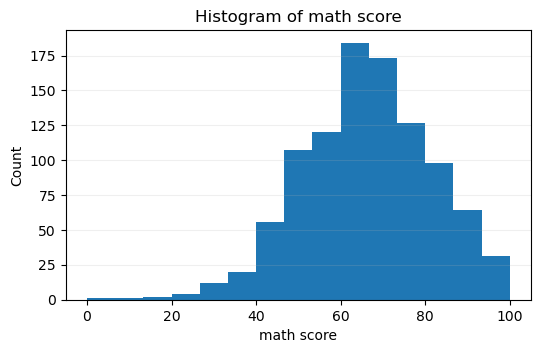

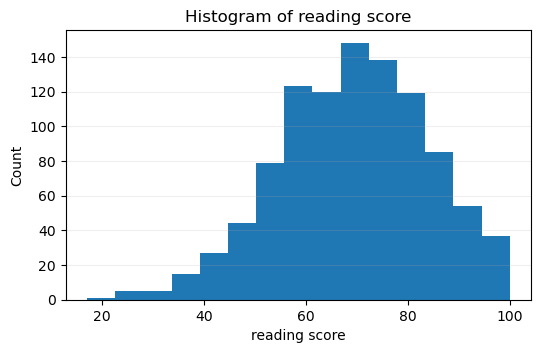

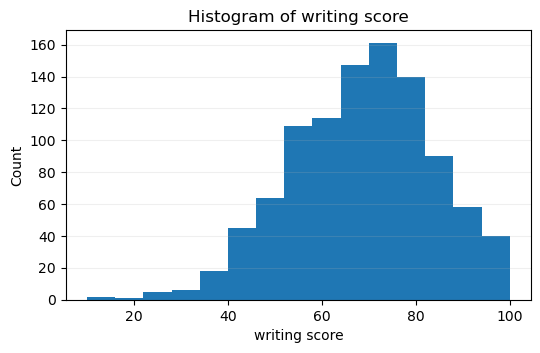

In [7]:
# Plot histograms
for col in score_cols:
    plt.figure(figsize=(6,3.5))
    plt.hist(df[col].dropna(), bins=15)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col); plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.2)
    plt.show()


--- Group comparisons by 'gender' ---
Groups: ['female' 'male']


math score                        reading score                         \
            count    mean     std median         count    mean     std median   
gender                                                                          
female        518  63.633  15.491   65.0           518  72.608  14.378   73.0   
male          482  68.728  14.356   69.0           482  65.473  13.932   66.0   

       writing score                         
               count    mean     std median  
gender                                       
female           518  72.467  14.845   74.0  
male             482  63.311  14.114   64.0

<Figure size 600x350 with 0 Axes>

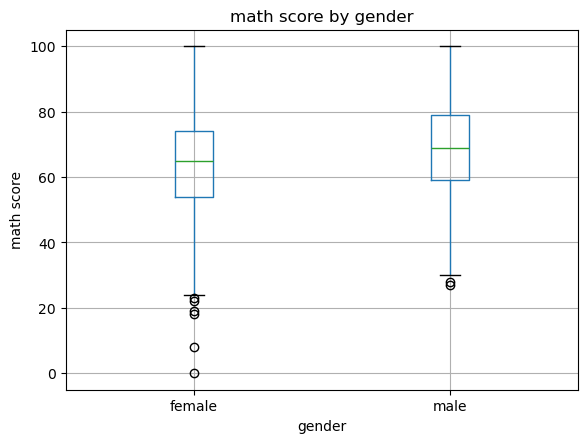

<Figure size 600x350 with 0 Axes>

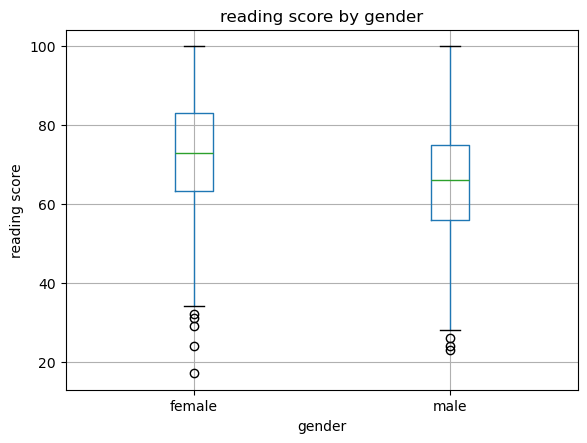

<Figure size 600x350 with 0 Axes>

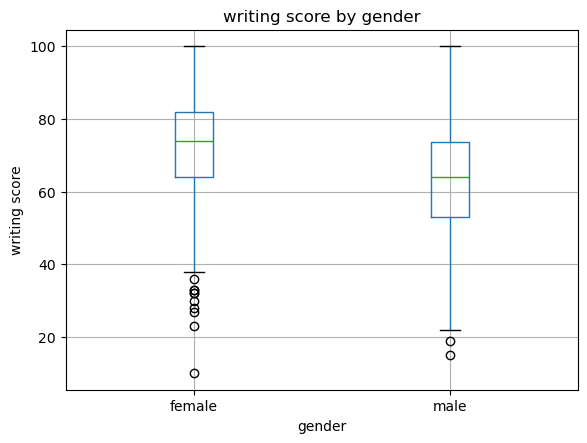


math score: t-test p=0.0000; Mann-Whitney p=0.0000

reading score: t-test p=0.0000; Mann-Whitney p=0.0000

writing score: t-test p=0.0000; Mann-Whitney p=0.0000


In [11]:

# Step 5: Group comparisons example: male vs female
group_var = 'gender' if 'gender' in df.columns else 'sex' if 'sex' in df.columns else None
if group_var:
    print(f"\n--- Group comparisons by '{group_var}' ---")
    groups = df[group_var].unique()
    print("Groups:", groups)
    summary_by_group = df.groupby(group_var)[score_cols].agg(['count','mean','std','median'])
    display(summary_by_group)

    # Boxplots
    for col in score_cols:
        plt.figure(figsize=(6,3.5))
        df.boxplot(column=col, by=group_var)
        plt.title(f'{col} by {group_var}')
        plt.suptitle(''); plt.xlabel(group_var); plt.ylabel(col)
        plt.show()

    # Statistical test: t-test (if approx normal) otherwise Mann-Whitney
    for col in score_cols:
        groups_data = [df[df[group_var]==g][col].dropna() for g in groups]
        # Check normality via sample size heuristic and skewness: if n>30 and not extreme skew, t-test ok
        tstat, pval = stats.ttest_ind(groups_data[0], groups_data[1], equal_var=False)
        mw_stat, mw_p = stats.mannwhitneyu(groups_data[0], groups_data[1], alternative='two-sided')
        print(f"\n{col}: t-test p={pval:.4f}; Mann-Whitney p={mw_p:.4f}")
else:
    print("No obvious gender/sex column found for group comparison. Choose another grouping column (e.g., 'race/ethnicity' or 'lunch').")


In [12]:
# Saving a small report dataframe 
report_table = centre.join(spread).join(shape_stats)
report_table.to_csv('exercise1_summary_stats.csv', index=True)
print("\nSummary table saved to exercise1_summary_stats.csv")


Summary table saved to exercise1_summary_stats.csv
